In [15]:
import pandas as pd
import numpy as np
import seaborn as sns

In [16]:
train_df = pd.read_csv('../datasets/train_energy_data.csv')
test_df = pd.read_csv('../datasets/test_energy_data.csv')

In [17]:
train_df_encoded = pd.get_dummies(train_df, columns=['Building Type', 'Day of Week'])

train_df_encoded = train_df_encoded.astype(int)

print(train_df_encoded.head())


   Square Footage  Number of Occupants  Appliances Used  Average Temperature  \
0               0                   76               10                   29   
1           47156                   66               45                   16   
2           26399                   37               17                   14   
3           18122                   14               41                   32   
4           20350                   26               18                   11   

   Energy Consumption  Building Type_Commercial  Building Type_Industrial  \
0                2428                         0                         0   
1                5616                         1                         0   
2                3850                         0                         1   
3                3055                         0                         0   
4                3781                         1                         0   

   Building Type_Residential  Day of Week_Weekday  Day o

In [18]:
x_train = train_df_encoded.drop('Energy Consumption', axis=1)
y_train = train_df_encoded['Energy Consumption']

In [19]:
test_df_encoded = pd.get_dummies(test_df, columns=['Building Type', 'Day of Week'])

test_df_encoded = test_df_encoded.astype(int)

print(test_df_encoded.head())


   Square Footage  Number of Occupants  Appliances Used  Average Temperature  \
0           24563                   15                4                   28   
1           27583                   56               23                   23   
2           45313                    4               44                   33   
3           41625                   84               17                   27   
4           36720                   58               47                   17   

   Energy Consumption  Building Type_Commercial  Building Type_Industrial  \
0                2865                         0                         0   
1                4283                         1                         0   
2                5067                         1                         0   
3                4624                         0                         0   
4                4820                         0                         0   

   Building Type_Residential  Day of Week_Weekday  Day o

In [20]:
x_test = test_df_encoded.drop('Energy Consumption', axis=1)
y_test = test_df_encoded['Energy Consumption']

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(x_train_scaled, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [25]:
y_pred = model.predict(x_test_scaled)
print("Predictions (first 10):")
for i, pred in enumerate(y_pred[:10]):
    print(f"{i+1}. {pred:.2f} kWh")

Predictions (first 10):
1. 2833.41 kWh
2. 4612.09 kWh
3. 5272.70 kWh
4. 4172.94 kWh
5. 4783.56 kWh
6. 4969.55 kWh
7. 4544.06 kWh
8. 2423.12 kWh
9. 4350.06 kWh
10. 4839.40 kWh


In [26]:
comparison_df = pd.DataFrame({
    'Actual Energy Consumption (kWh)': y_test.values,
    'Predicted Energy Consumption (kWh)': y_pred
})

comparison_df = comparison_df.round(2)

print(comparison_df.head())


   Actual Energy Consumption (kWh)  Predicted Energy Consumption (kWh)
0                             2865                             2833.41
1                             4283                             4612.08
2                             5067                             5272.70
3                             4624                             4172.94
4                             4820                             4783.56


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [28]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [29]:
print("\n--- Random Forest Evaluation ---")
print(f"MAE: {mae:.2f} kWh")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2 * 100:.2f}%")



--- Random Forest Evaluation ---
MAE: 156.26 kWh
MSE: 38958.20
RMSE: 197.38
R² Score: 94.32%


To provide a clear visual summary of the model's performance, the actual values are compared with the predicted values using a scatter plot. This plot helps to visualize how closely the model's predictions match the actual values. Points closer to the line represent more accurate predictions, while points farther away indicate larger prediction errors.

The scatter plot below illustrates this relationship between the actual and predicted values.

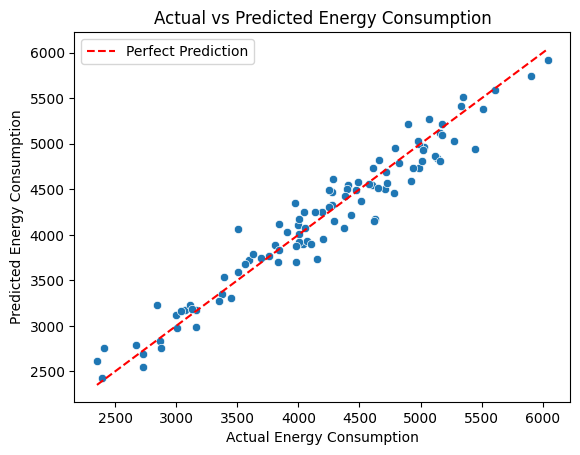

In [30]:
import matplotlib.pyplot as plt

sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label="Perfect Prediction")
plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.legend()
plt.show()
